У вас есть ноутбук circle_generator.ipynb Ваша задача сгенерировать изображения кружочков и натренировать нейронную сеть с архитектурой UNet на предмет сегментации кружочков на сгенерированных изображениях.
- Не забываем про разбиение на train/test/validation
- Считать значение лосса и метрики на трейне и тесте во время обучения
- Построить график лосса на трейне и тесте после обучения
- Оценить качество модели на валидации на выбранной метрике.

---

Настройки решения:
- разделение: train/test/validation = 90/5/5
- метрика качества: IoU
- функция потерь: Focal Loss
- модель: U-Net с предварительно обученным encoder (`segmentation_models_pytorch`)

In [98]:
!pip install -q segmentation-models-pytorch albumentations torchmetrics

In [99]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from sklearn.model_selection import train_test_split
from torchmetrics.classification import BinaryJaccardIndex
import segmentation_models_pytorch as smp

import warnings
warnings.filterwarnings("ignore")

In [100]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [101]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Пути и источник данных

In [102]:
base_dir = '/content/drive/.../generated_circles_100'
annote_dir = f'{base_dir}/masks'
images_dir = f'{base_dir}/images'

assert Path(images_dir).exists(), f'Images folder not found: {images_dir}'
assert Path(annote_dir).exists(), f'Masks folder not found: {annote_dir}'

image_files = sorted([p.name for p in Path(images_dir).glob('*.png')])
mask_files = sorted([p.name for p in Path(annote_dir).glob('*.png')])

assert len(image_files) == len(mask_files) > 0, 'Image/mask count mismatch or empty dataset'
assert image_files == mask_files, 'Image and mask names must match 1:1'

print('Всего пар изображение-маска:', len(image_files))

Всего пар изображение-маска: 100


Изначальный shape изображения: (572, 572, 3)
Изначальный shape маски: (572, 572)


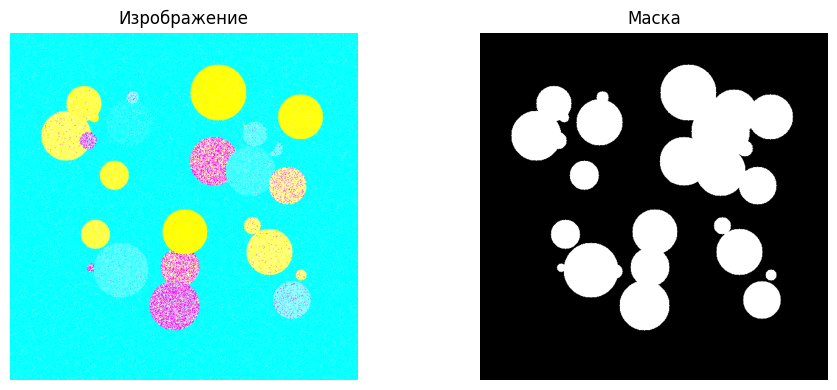

In [103]:
sample_name = image_files[0]
img = cv2.cvtColor(cv2.imread(f'{images_dir}/{sample_name}'), cv2.COLOR_BGR2RGB)
msk = cv2.imread(f'{annote_dir}/{sample_name}', cv2.IMREAD_GRAYSCALE)

print('Изначальный shape изображения:', img.shape)
print('Изначальный shape маски:', msk.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img)
ax[0].set_title('Изрображение')
ax[0].axis('off')
ax[1].imshow(msk, cmap='gray')
ax[1].set_title('Маска')
ax[1].axis('off')
plt.tight_layout()
plt.show()

### Разделение данных 90/5/5

In [104]:
train_files, temp_files = train_test_split(
    image_files,
    test_size=0.10,
    random_state=SEED,
    shuffle=True,
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
)

print(f'train: {len(train_files)} ({len(train_files)/len(image_files):.0%})')
print(f'val  : {len(val_files)} ({len(val_files)/len(image_files):.0%})')
print(f'test : {len(test_files)} ({len(test_files)/len(image_files):.0%})')

train: 90 (90%)
val  : 5 (5%)
test : 5 (5%)


In [105]:
class CircleSegmentationDataset(Dataset):
    def __init__(self, file_names, images_dir, masks_dir, transform=None):
        self.file_names = file_names
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        name = self.file_names[idx]
        image = cv2.cvtColor(cv2.imread(f'{self.images_dir}/{name}'), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(f'{self.masks_dir}/{name}', cv2.IMREAD_GRAYSCALE)

        # Для сегментации ожидаем целевую маску как бинарную (0/1).
        mask = (mask > 127).astype(np.float32)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image, mask = transformed['image'], transformed['mask']

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image), torch.tensor(mask)


In [106]:
# Исходные сгенерированные изображения имеют размер 572x572.
# Изменяем размер до 256x256 для более быстрой и стабильной тренировки.
image_size = 256

train_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
])

eval_transform = A.Compose([
    A.Resize(image_size, image_size),
])

train_ds = CircleSegmentationDataset(train_files, images_dir, annote_dir, transform=train_transform)
val_ds = CircleSegmentationDataset(val_files, images_dir, annote_dir, transform=eval_transform)
test_ds = CircleSegmentationDataset(test_files, images_dir, annote_dir, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)

(90, 5, 5)

## Определение модели и тренировка

In [107]:
import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

model = smp.Unet(
    encoder_name='resnet18',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
)
model = model.to(device)

criterion = smp.losses.FocalLoss(mode='binary')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)

model

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [108]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_iou = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits)
        batch_iou = iou_metric(probs, masks.int())

        total_loss += loss.item() * images.size(0)
        total_iou += batch_iou.item() * images.size(0)

    n = len(loader.dataset)
    return total_loss / n, total_iou / n


In [109]:
epochs = 6
best_val_iou = -1.0
best_state = None
history = {'train_loss': [], 'train_iou': [], 'val_loss': [], 'val_iou': []}

for epoch in range(1, epochs + 1):
    train_loss, train_iou = run_epoch(model, train_loader, optimizer=optimizer)
    with torch.no_grad():
        val_loss, val_iou = run_epoch(model, val_loader, optimizer=None)

    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(
        f'Epoch {epoch:02d}/{epochs} | '
        f'train_loss={train_loss:.4f} train_IoU={train_iou:.4f} | '
        f'val_loss={val_loss:.4f} val_IoU={val_iou:.4f}'
    )

Epoch 01/6 | train_loss=0.1068 train_IoU=0.5885 | val_loss=1.5109 val_IoU=0.3287
Epoch 02/6 | train_loss=0.0357 train_IoU=0.8173 | val_loss=0.1993 val_IoU=0.5111
Epoch 03/6 | train_loss=0.0276 train_IoU=0.8494 | val_loss=0.0260 val_IoU=0.8631
Epoch 04/6 | train_loss=0.0246 train_IoU=0.8606 | val_loss=0.0203 val_IoU=0.8913
Epoch 05/6 | train_loss=0.0218 train_IoU=0.8789 | val_loss=0.0176 val_IoU=0.8999
Epoch 06/6 | train_loss=0.0213 train_IoU=0.8812 | val_loss=0.0173 val_IoU=0.9035


In [110]:
if best_state is not None:
    model.load_state_dict(best_state)

with torch.no_grad():
    test_loss, test_iou = run_epoch(model, test_loader, optimizer=None)

print(f'Лучший IoU на валидации: {best_val_iou:.4f}')
print(f'Loss на тесте: {test_loss:.4f}')
print(f'IoU  на тесте: {test_iou:.4f}')

Лучший IoU на валидации: 0.9035
Loss на тесте: 0.0214
IoU  на тесте: 0.8849


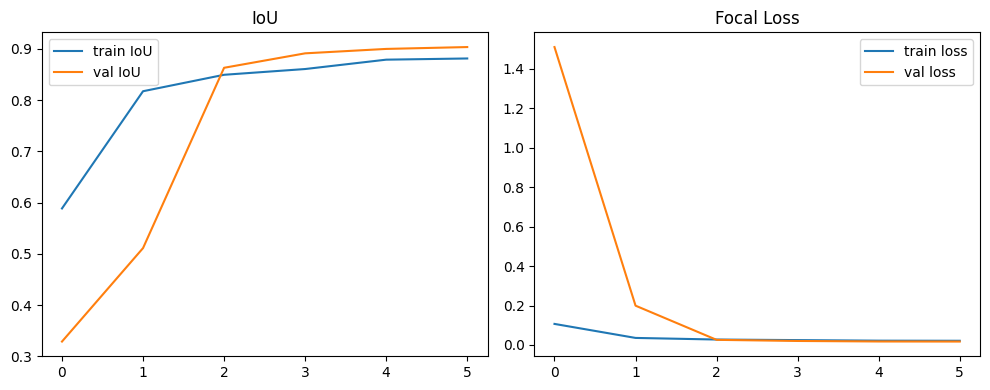

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history['train_iou'], label='train IoU')
ax[0].plot(history['val_iou'], label='val IoU')
ax[0].set_title('IoU')
ax[0].legend()
ax[1].plot(history['train_loss'], label='train loss')
ax[1].plot(history['val_loss'], label='val loss')
ax[1].set_title('Focal Loss')
ax[1].legend()
plt.tight_layout()
plt.show()

## Оценка качества модели на тестовых данных

In [112]:
model.eval()

# Значение IoU определяется для всего тестового набора  (для каждого образца + на совокупности)
all_iou_scores = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        probs = torch.sigmoid(model(images))
        preds_bin = (probs > 0.5).float()

        preds_np = preds_bin.cpu().numpy()
        masks_np = masks.cpu().numpy()

        for i in range(preds_np.shape[0]):
            gt = masks_np[i, 0] > 0.5
            pr = preds_np[i, 0] > 0.5
            intersection = np.logical_and(gt, pr).sum()
            union = np.logical_or(gt, pr).sum()
            iou = intersection / (union + 1e-8)
            all_iou_scores.append(float(iou))

print('IoU для каждого образца:')
for idx, score in enumerate(all_iou_scores):
    print(f'  sample {idx:03d}: IoU = {score:.4f}')

print('\nIoU на совокупности:')
print(f'  mean IoU  : {np.mean(all_iou_scores):.4f}')
print(f'  median IoU: {np.median(all_iou_scores):.4f}')
print(f'  min IoU   : {np.min(all_iou_scores):.4f}')
print(f'  max IoU   : {np.max(all_iou_scores):.4f}')

IoU для каждого образца:
  sample 000: IoU = 0.8873
  sample 001: IoU = 0.8434
  sample 002: IoU = 0.9298
  sample 003: IoU = 0.9202
  sample 004: IoU = 0.8497

IoU на совокупности:
  mean IoU  : 0.8861
  median IoU: 0.8873
  min IoU   : 0.8434
  max IoU   : 0.9298


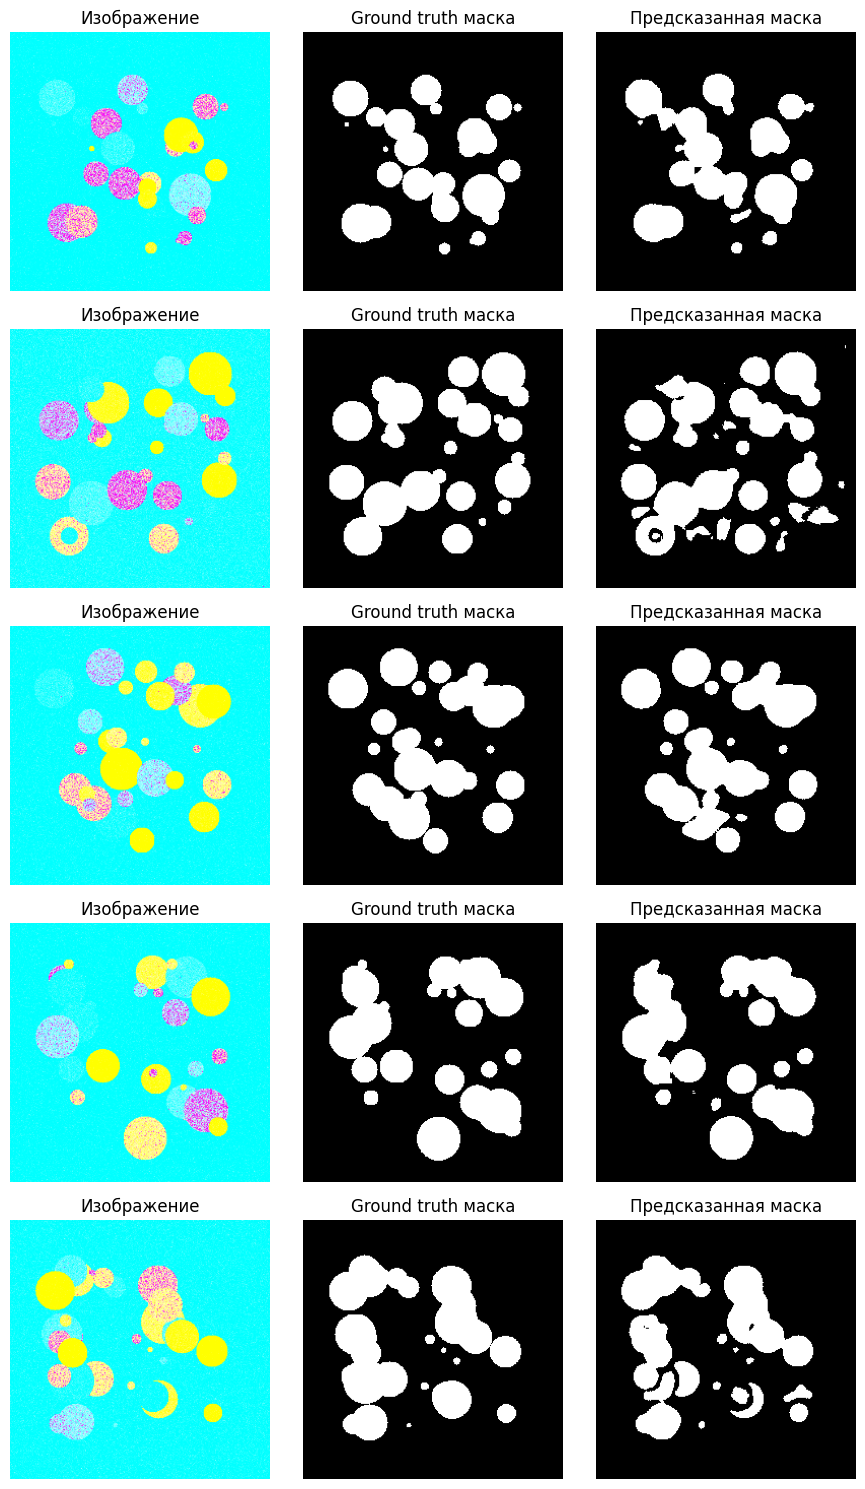

In [113]:
model.eval()
images, masks = next(iter(test_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(images))

images_np = images.cpu().numpy()
masks_np = masks.cpu().numpy()
preds_np = (preds.cpu().numpy() > 0.5).astype(np.float32)

n_show = 5
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)

for i in range(n_show):
    axes[i, 0].imshow(np.transpose(images_np[i], (1, 2, 0)))
    axes[i, 0].set_title('Изображение')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(masks_np[i, 0], cmap='gray')
    axes[i, 1].set_title('Ground truth маска')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(preds_np[i, 0], cmap='gray')
    axes[i, 2].set_title('Предсказанная маска')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()